# The Ethiopia Kiremt 2026 Drought Outlook — reproduced with Rosetta + DeepScale

*A worked walk-through of the CHC / FEWS&nbsp;NET deck **"Ethiopia Likely to
Experience Very Poor Rains in 2026"** (Chris Funk, July 2026) — the outlook for
the June–September **Kiremt** rains — rebuilt with `rosetta` and `deepscale`.*

---

### What the deck concludes

The deck's headline is a very poor Kiremt 2026, from a **convergence of evidence**:
rainfall observed so far, El&nbsp;Niño **analog** years, a **dynamic forecast**,
and a West-Pacific **teleconnection** cross-check — all pointing dry.

### What this notebook builds — and on which data

`rosetta` for acquisition, `deepscale` for the SMPG logic. The deck's observed
layer is **CHIRPS** and its forecast **CHIRPS-GEFS**; we use **ERA5** for the
gridded observed maps and **NMME** for the dynamic forecast, because **CHIRPS has
no data for the 2026 season yet**, so it cannot supply the June anchor or the July
forecast. ERA5 is the standard reanalysis stand-in for the 2026 fields; CHIRPS is
used wherever the historical record suffices (§9–10). A correspondence check (§10)
measures the substitution.

The substitution is not free: the NMME July forecast is near climatology, so —
unlike the deck's drier CHIRPS-GEFS — the *dynamic* leg **softens** rather than
sharpens the outlook. We flag it at each stage.

## Setup

In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import rosetta
import deepscale as ds
import deck_style as deck
from datetime import datetime
from deepscale.registry import get_method

GHA        = [-13.5, 24.5, 20.5, 53.0]      # Greater Horn of Africa (deck monitoring extent)
REGION     = [3.0, 15.0, 33.0, 48.0]        # Ethiopia (SMPG analysis extent)
SEASON     = "JJAS"                          # the Kiremt season
TARGET     = 2026
BASELINE   = (1991, 2020)                    # index (Niño-3.4) anomaly baseline (standard ENSO baseline)
CANDIDATES = list(range(1991, 2026))         # ONE window for climatology / percentile baseline / analog pool
woredas = gpd.read_file("data/eth_adm3_woreda.geojson")
print(f"{len(woredas)} woredas loaded")

690 woredas loaded


## 1 · Fetch the season

One `fetch()` returns normalized ERA5 monthly precipitation over the Greater Horn;
we subset Ethiopia and stack it into one Kiremt season per year. The percentile
baseline and the analog pool use a single window (`CANDIDATES`, 1991–2025); the
Niño-3.4 index uses the standard 1991–2020 anomaly baseline.

In [3]:
era_gha = rosetta.fetch("obs/era5", "precip", hindcast=(1991, 2026), region=GHA, verbose=False)["precip"]
era = era_gha.sel(lat=slice(REGION[0], REGION[1]), lon=slice(REGION[2], REGION[3]))
climatology = ds.seasonal_stack(era, SEASON, years=CANDIDATES)
print("Ethiopia subset:", dict(era.sizes), "| ERA5 latest month:", str(era.time.values[-1])[:7])

Ethiopia subset: {'time': 426, 'lat': 49, 'lon': 61} | ERA5 latest month: 2026-06


## 1b · The forecast leg — a bias-corrected NMME July field

The dynamic July forecast is the **NMME** (three models), gridded-quantile-mapped
onto ERA5. We build it over the GHA extent and subset Ethiopia, and compare the
Ethiopia forecast against the Ethiopia July climatology (like with like).

In [4]:
MODELS = ["nmme/cansipsic4", "nmme/ccsm4", "nmme/cesm1"]

def nmme_july(y, region):
    fields = []
    for m in MODELS:
        d = rosetta.fetch(m, "precip", init=f"{y}-06", target=(datetime(y,7,1), datetime(y,7,31)),
                          hindcast=(y,y), region=region, verbose=False)["precip"]
        if d.sizes.get("init_time", 0) == 0:            # provider gap -> use the other models
            continue
        f = d.isel(init_time=0, drop=True)
        if float(f.mean()) > 20:                        # implausible July rate -> reject a corrupt model-year
            continue
        fields.append(f)
    return xr.concat(xr.align(*fields, join="inner"), dim="model").mean("model")

train = range(2000, 2024)
hind_gha     = xr.concat([nmme_july(y, GHA) for y in train], dim=pd.Index(list(train), name="year"))
era_july_gha = era_gha.sel(time=era_gha.time.dt.month == 7).groupby("time.year").mean("time").sel(year=list(train))

qm = get_method("qm")(); qm.fit(hind_gha, era_july_gha)
july_fc_gha = qm.predict(nmme_july(TARGET, GHA)).mean("member")
july_fc = july_fc_gha.sel(lat=slice(REGION[0], REGION[1]), lon=slice(REGION[2], REGION[3]))

eth_july_clim = (era.sel(time=era.time.dt.month == 7).groupby("time.year").mean("time")
                    .sel(year=list(train)).mean(["lat", "lon", "year"]))
print(f"bias-corrected July 2026 forecast (Ethiopia): {float(july_fc.mean()):.2f} mm/day "
      f"(Ethiopia July climatology {float(eth_july_clim):.2f} mm/day)")

bias-corrected July 2026 forecast (Ethiopia): 2.72 mm/day (Ethiopia July climatology 3.04 mm/day)


## 2 · Monitor the season to date (Stage 1)

How the rainfall *so far* ranks against history, over the whole Greater Horn, two ways — observations only (June), and observations + the short-range forecast (June + first-half July).

<figure style="margin:1.1em 0;padding:0.6em;border:1px solid #ddd;border-radius:8px;background:#fafafa">
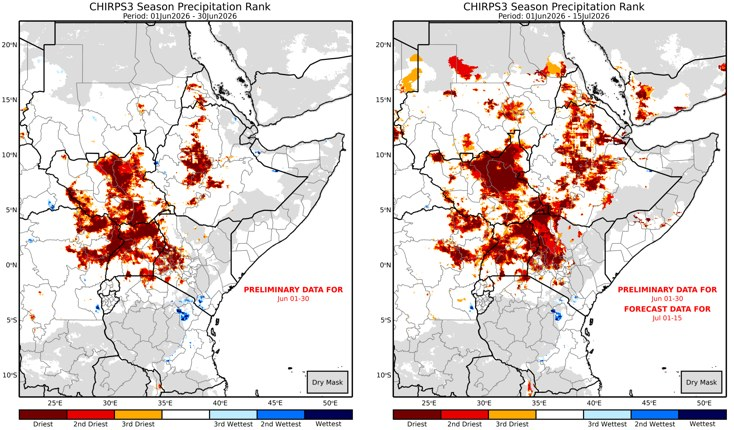
<figcaption style="font-size:0.85em;color:#555;margin-top:0.4em">
<b>CHC deck &middot; slide 6</b> &mdash; CHIRPS season rank — observations only (left) and observations + forecast (right)</figcaption>
</figure>

Both panels over the GHA extent, percentiles taken against the `CANDIDATES` climatology:

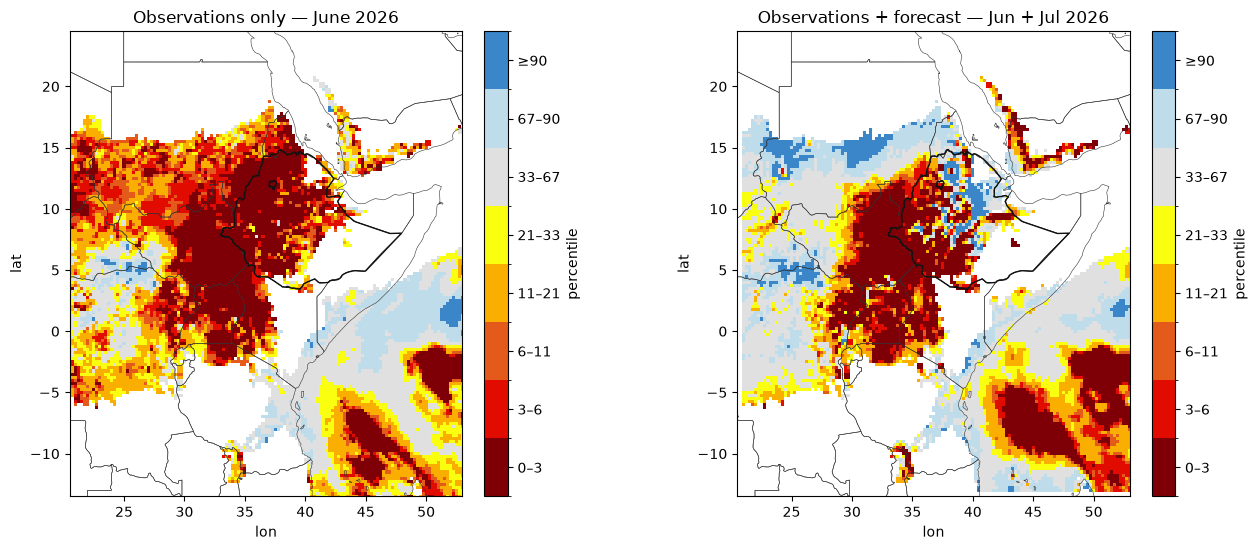

In [5]:
june = era_gha.sel(time=era_gha.time.dt.month == 6).groupby("time.year").mean("time")
july = era_gha.sel(time=era_gha.time.dt.month == 7).groupby("time.year").mean("time")

dry_mask = ((june + july) / 2).sel(year=CANDIDATES).mean("year") > 0.3
june_pct   = ds.percentile_of(june.sel(year=TARGET), june.sel(year=CANDIDATES)).where(dry_mask)
junjul_2026 = (june.sel(year=TARGET) + july_fc_gha) / 2
junjul_clim = ((june + july) / 2).sel(year=CANDIDATES)
junjul_2026, junjul_clim = xr.align(junjul_2026, junjul_clim, join="inner")
junjul_pct = ds.percentile_of(junjul_2026, junjul_clim).where(dry_mask)

borders = ds.natural_earth_borders(region=GHA)
eth_outline = woredas.dissolve()
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6))
ds.plot_field_map(june_pct, ax=axes[0], classes=deck.PERCENTILE_CLASSES, boundaries=borders,
                  cbar_label="percentile", title="Observations only — June 2026")
ds.plot_field_map(junjul_pct, ax=axes[1], classes=deck.PERCENTILE_CLASSES, boundaries=borders,
                  cbar_label="percentile", title="Observations + forecast — Jun + Jul 2026")
for a in axes:
    eth_outline.boundary.plot(ax=a, color="#111", linewidth=1.0)
    a.set_xlim(GHA[2], GHA[3]); a.set_ylim(GHA[0], GHA[1])
fig.tight_layout(); plt.show()

The dry signal concentrates on the Ethiopian highlands (outlined), consistent with
the deck. The observations+forecast panel is a little *less* extreme than the
deck's, because our NMME July is near normal — the forecast substitute, not the
observed record.

## 3 · The analog years (Stage 3a) — a forecast anchor, and the deck's curation

The analog selection needs a 2026 Kiremt-season Niño-3.4. Since only June 2026 is
observed, the appropriate object is a **forecast** of the JJAS season — which is
also what the deck's "rapidly intensifying El&nbsp;Niño" premise is. We compute it
from the NMME models (June init), splice it onto the observed history, and select
analogs as the **moderate-to-very-strong El&nbsp;Niño years** the deck curates:

In [6]:
sst = rosetta.fetch("obs/ersst-v5", "sst", hindcast=(1991, 2026), verbose=False)["sst"]

# Niño-3.4 as a RAW box-mean SST; we form the anomaly ourselves against the observed
# 1991-2020 climatology, so a single-year forecast field (no baseline of its own) can
# still be anomalised. (The forecast anchor is thus a perfect-prognosis estimate:
# model SST minus the OBSERVED climatology; any model mean-bias is folded in, which is
# acceptable for choosing *which* analog years 2026 resembles.)
n34_box = ds.Index.custom(name="n34", regions={"n34": [-5, 5, 190, 240]},
                          combine=lambda b: b["n34"], transform="raw", weights="cos_lat")

# observed JJAS Niño-3.4 (absolute) for COMPLETE seasons only (<= 2025), then anomalise
jjas_obs = (sst.sel(time=sst.time.dt.month.isin([6,7,8,9]) & (sst.time.dt.year <= 2025))
              .groupby("time.year").mean("time"))
n34_obs_abs = n34_box.reduce(jjas_obs)
clim = float(n34_obs_abs.sel(year=slice(BASELINE[0], BASELINE[1])).mean())
nino34_obs = n34_obs_abs - clim

# 2026 Kiremt-season Niño-3.4 as an NMME June-init FORECAST (not an observed month)
def nmme_jjas_sst(y):
    fields = []   # tropical Pacific band covers the Niño-3.4 box
    for m in MODELS:
        d = rosetta.fetch(m, "sst", init=f"{y}-06", target=(datetime(y,6,1), datetime(y,9,30)),
                          region=[-15,15,150,280], hindcast=(y,y), verbose=False)["sst"]
        if d.sizes.get("init_time", 0) == 0:
            continue
        fields.append(d.isel(init_time=0).mean("member"))
    return xr.concat(xr.align(*fields, join="inner"), dim="model").mean("model")
nino34_fc = float(n34_box.reduce(nmme_jjas_sst(TARGET).expand_dims(year=[TARGET])).sel(year=TARGET)) - clim

nino34 = xr.concat([nino34_obs, xr.DataArray([nino34_fc], dims="year", coords={"year":[TARGET]})], dim="year")
print(f"2026 JJAS Niño-3.4 = {nino34_fc:+.2f} °C  (NMME June-init FORECAST anomaly vs 1991-2020 obs)")

# moderate-to-very-strong El Niño years = the deck's analog class
NINO_THR = 0.5                                            # JJAS developing-El-Niño threshold
cand = nino34.sel(year=CANDIDATES)
strong = sorted(int(y) for y, v in zip(cand.year.values, cand.values) if float(v) >= NINO_THR)
analogs = ds.analogs_from_index(nino34, target_year=TARGET, n=len(strong), candidates=strong)
print(f"moderate-to-very-strong El Niño analogs (JJAS Niño-3.4 >= {NINO_THR}):")
for y in strong:
    print(f"    {y}: {float(nino34.sel(year=y)):+.2f} °C")

2026 JJAS Niño-3.4 = +1.66 °C  (NMME June-init FORECAST anomaly vs 1991-2020 obs)
moderate-to-very-strong El Niño analogs (JJAS Niño-3.4 >= 0.5):
    1991: +0.59 °C
    1997: +1.66 °C
    2002: +0.85 °C
    2004: +0.54 °C
    2009: +0.51 °C
    2015: +1.69 °C
    2023: +1.20 °C


The anchor is a **forecast** of a developing El&nbsp;Niño, and the analog set is the
**moderate-to-very-strong** El&nbsp;Niño years — matching the deck's stated
curation. Note the outlook is *conditional* on that forecast El&nbsp;Niño
developing, so its confidence tracks the ENSO forecast's own uncertainty.

## 4 · El-Niño rainfall relationship (Stage 3a diagnostic)

A scatter (stronger JAS **RONI** → lower Ethiopian JAS rainfall) beside the **composite map** — per cell, the share of analog years that were below-normal.

<figure style="margin:1.1em 0;padding:0.6em;border:1px solid #ddd;border-radius:8px;background:#fafafa">
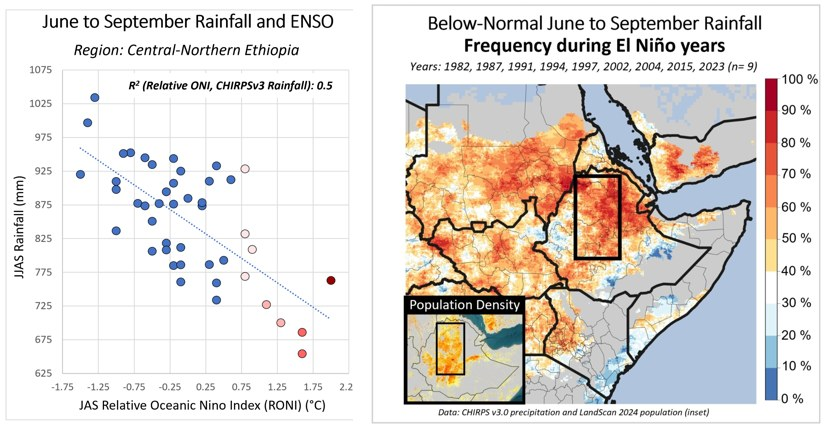
<figcaption style="font-size:0.85em;color:#555;margin-top:0.4em">
<b>CHC deck &middot; slide 8</b> &mdash; Slide 8 — JAS RONI vs rainfall (left) and the below-normal analog composite (right)</figcaption>
</figure>

Both on one row, with the computed R²:

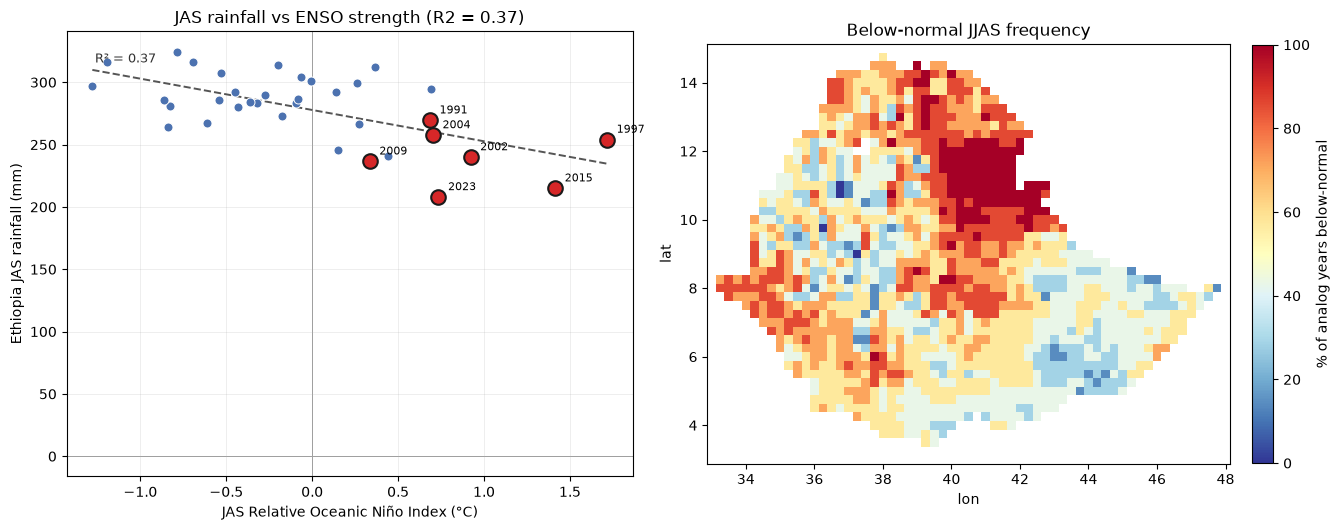

ENSO-rainfall fit: R2 = 0.37  (ERA5 from 1991; the deck reports ~0.5 on CHIRPS from 1981)
region-mean below-normal frequency across analogs: 60% (coin-flip = 33%)


In [7]:
jas_sst = sst.sel(time=sst.time.dt.month.isin([7,8,9])).groupby("time.year").mean("time")
roni_jas = ds.Index.named("roni", baseline=BASELINE).reduce(jas_sst)
jas_rain = era.sel(time=era.time.dt.month.isin([7,8,9])).groupby("time.year").mean("time").mean(["lat","lon"]) * 92
jas_rain.name = "jas_rainfall_mm"
yrs = [y for y in CANDIDATES if y in roni_jas.year.values]
r2 = float(np.corrcoef(roni_jas.sel(year=yrs).values, jas_rain.sel(year=yrs).values)[0,1])**2

step_dims = [d for d in climatology.dims if d not in ("year", "lat", "lon")]
jjas_total = climatology.sum(step_dims)
below_freq = ds.frequency_below(jjas_total.sel(year=sorted(analogs.years.tolist())), jjas_total, q=1/3) * 100

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4))
ds.plot_index_scatter(roni_jas.sel(year=yrs), jas_rain.sel(year=yrs), ax=axes[0],
        highlight=sorted(analogs.years.tolist()), highlight_color="#d62728", trendline=True,
        xlabel="JAS Relative Oceanic Niño Index (°C)", ylabel="Ethiopia JAS rainfall (mm)",
        title=f"JAS rainfall vs ENSO strength (R2 = {r2:.2f})")
ds.plot_field_map(below_freq, ax=axes[1], clip=woredas, cmap="RdYlBu_r", vmin=0, vmax=100,
        cbar_label="% of analog years below-normal", title="Below-normal JJAS frequency")
fig.tight_layout(); plt.show()
print(f"ENSO-rainfall fit: R2 = {r2:.2f}  (ERA5 from 1991; the deck reports ~0.5 on CHIRPS from 1981)")
print(f"region-mean below-normal frequency across analogs: {float(below_freq.mean()):.0f}% (coin-flip = 33%)")

The negative slope reproduces the deck's — warmer JAS RONI, drier Ethiopian rains —
with the analog years (red) at the warm, dry end. The R² is lower than the deck's
≈0.5, computed on the shorter ERA5 record from 1991.

## 5 · Scenario completion (Stage 3)

`complete()` splices observed-to-date rainfall with each analog year's remainder,
one end-of-season outcome per analog, and reads off the percentile:

In [8]:
obs = era.sel(time=(era.time.dt.year == TARGET) & (era.time.dt.month.isin([6,7,8,9])))
result = ds.complete(obs, analogs, climatology=climatology, season=SEASON, year=TARGET, cadence="monthly")
pct = result.percentile
print(f"end-of-season outlook: region-mean percentile {float(pct.mean()):.2f}; "
      f"{100*float((pct<0.21).mean()):.0f}% below 21st, {100*float((pct<0.33).mean()):.0f}% below 33rd")

end-of-season outlook: region-mean percentile 0.20; 68% below 21st, 80% below 33rd


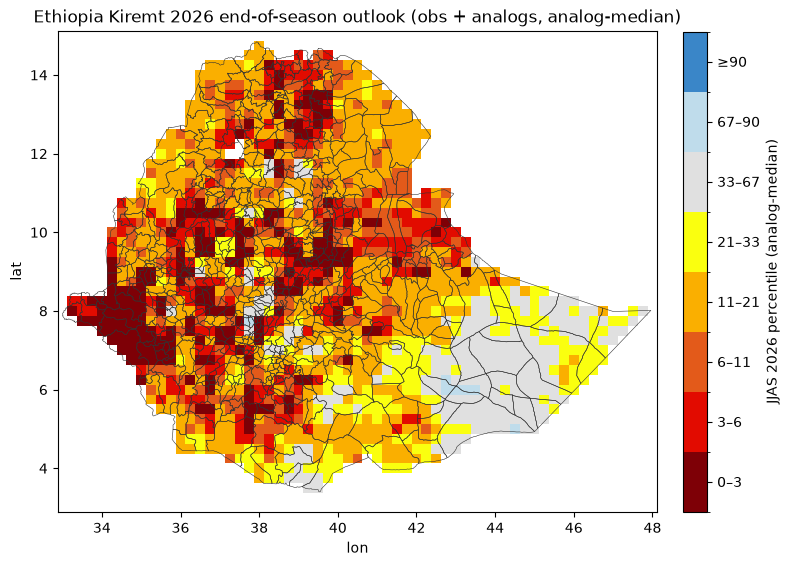

In [9]:
fig = ds.plot_field_map(pct, boundaries=woredas, clip=woredas, classes=deck.PERCENTILE_CLASSES,
                        cbar_label="JJAS 2026 percentile (analog-median)",
                        title="Ethiopia Kiremt 2026 end-of-season outlook (obs + analogs, analog-median)")
plt.show()

The analog-based outlook: a large share of the highlands below the 21st percentile.
The map shows the **median** of the analog scenarios, so it is a *conditional
analog-median* — a single number that does not convey the spread across the
individual analog completions. This obs+analog configuration, using no dynamic
forecast, is the part of the deck we match most directly.

## 6 · Woreda-level reporting and a district drill-down (Stage 3)

The SMPG reports at **woreda** level and pairs the choropleth with a single-district drill-down. The deck's illustrative district is **Sebeta Town** — a highland long-cycle-crop woreda just south-west of Addis.

<figure style="margin:1.1em 0;padding:0.6em;border:1px solid #ddd;border-radius:8px;background:#fafafa">
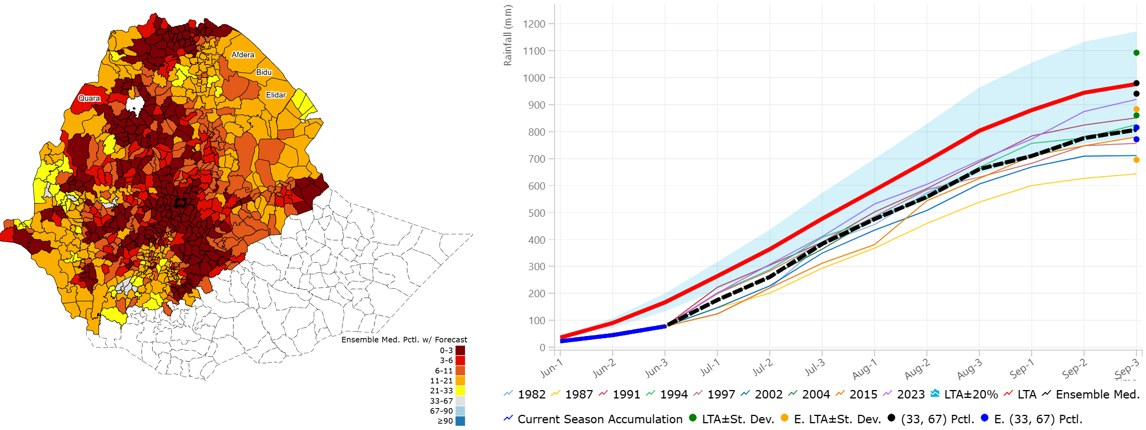
<figcaption style="font-size:0.85em;color:#555;margin-top:0.4em">
<b>CHC deck &middot; slide 12–13</b> &mdash; Slides 12–13 — the woreda percentile map (left) and a single-district accumulation (right)</figcaption>
</figure>

`rosetta.zonal` reduces the percentile field over all 690 woredas. ERA5's 0.25°
grid is coarser than many woredas, so we resample onto a fine mesh for coverage
(this copies, it does not add detail). For the drill-down we select a **highland
cropping district near Sebeta's location**, representative of the deck's example:

686/690 woredas resolved | highland drill-down: Alem Gena (percentile 0.03)


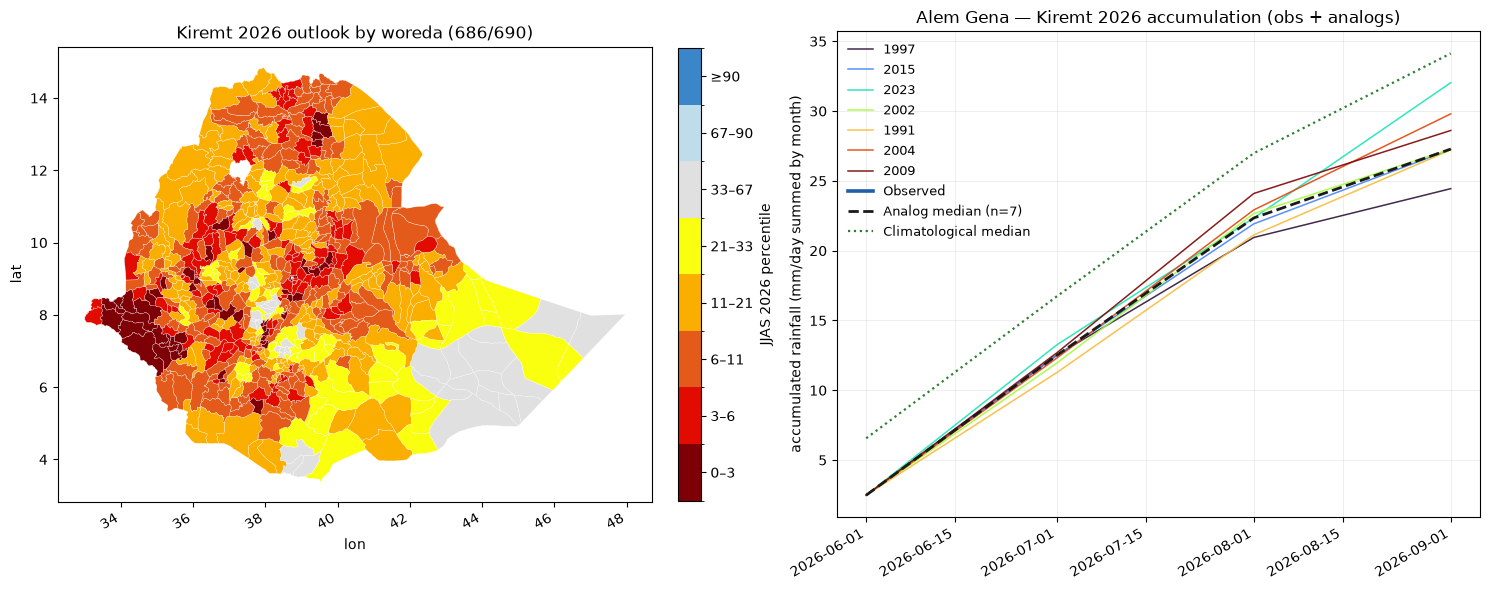

In [10]:
def to_woreda(field):
    fine_lat = np.arange(float(field.lat.min()), float(field.lat.max()), 0.05)
    fine_lon = np.arange(float(field.lon.min()), float(field.lon.max()), 0.05)
    fine = field.interp(lat=fine_lat, lon=fine_lon, method="nearest")
    return rosetta.zonal(fine, woredas, by="shapeID", label="shapeName",
                         stat="mean", all_touched=False).rename("percentile")

per_woreda = to_woreda(pct)
resolved = int(np.isfinite(per_woreda.values).sum())

# highland cropping district near Sebeta Town (~8.92 N, 38.62 E)
sebeta = Point(38.62, 8.92)
woredas["_d"] = woredas.geometry.centroid.distance(sebeta)
sub = woredas.nsmallest(1, "_d"); wname = sub["shapeName"].iloc[0]
w_series = rosetta.zonal(era, sub, stat="mean", all_touched=True).isel(region=0)
w_clim = ds.seasonal_stack(w_series, SEASON, years=CANDIDATES)
w_obs  = w_series.sel(time=(w_series.time.dt.year == TARGET) & (w_series.time.dt.month.isin([6,7,8,9])))
res_w  = ds.complete(w_obs, analogs, climatology=w_clim, season=SEASON, year=TARGET, cadence="monthly")
print(f"{resolved}/690 woredas resolved | highland drill-down: {wname} "
      f"(percentile {float(res_w.percentile.mean()):.2f})")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ds.plot_choropleth(per_woreda, woredas, by="shapeID", ax=axes[0], classes=deck.PERCENTILE_CLASSES,
                   cbar_label="JJAS 2026 percentile", title=f"Kiremt 2026 outlook by woreda ({resolved}/690)")
ds.plot_accumulation_scenarios(res_w, ax=axes[1], climatology=w_clim, color_by_scenario=True,
        ylabel="accumulated rainfall (mm/day summed by month)",
        title=f"{wname} — Kiremt 2026 accumulation (obs + analogs)")
fig.tight_layout(); plt.show()

The district outlook shows widespread below-normal rainfall in the cropping
highlands, with the highland drill-down's analog scenarios fanning below its local
climatological band — a representative case, not the single driest cell.

## 7 · Add the dynamic forecast (Stage 2)

Config B replaces the analog-filled July with the NMME forecast. This is where our
substitute and the deck diverge:

In [11]:
july_fc_t = july_fc.expand_dims(time=[np.datetime64(f"{TARGET}-07-01")])
resB = ds.complete(obs, analogs, climatology=climatology, season=SEASON, year=TARGET,
                   cadence="monthly", forecast=july_fc_t, overlap="observed")
pctB = resB.percentile
print(f"config A (obs+analogs):          {100*float((pct<0.21).mean()):.0f}% below 21st, {100*float((pct<0.33).mean()):.0f}% below 33rd")
print(f"config B (obs+forecast+analogs): {100*float((pctB<0.21).mean()):.0f}% below 21st, {100*float((pctB<0.33).mean()):.0f}% below 33rd")

config A (obs+analogs):          68% below 21st, 80% below 33rd
config B (obs+forecast+analogs): 53% below 21st, 67% below 33rd


Our config B is *wetter* than config A (the near-climatology NMME July), whereas
the deck's config B was *drier* (its CHIRPS-GEFS forecast an unusually dry July).
So we do **not** reproduce the deck's headline intensification — the dynamic step
softens here. The softening is the **forecast source**, not the ERA5 observations:
because every percentile is taken within ERA5's own distribution, the ERA5↔CHIRPS
mean bias (§10) cancels from the ranking.

## 8 · Should we trust the dynamic forecast? (Stage 4)

The deck's sub-seasonal ensemble scores R² ≈ 0.48 for July; we verify the forecast
we actually use — standardized NMME July vs standardized observed Kiremt rainfall:

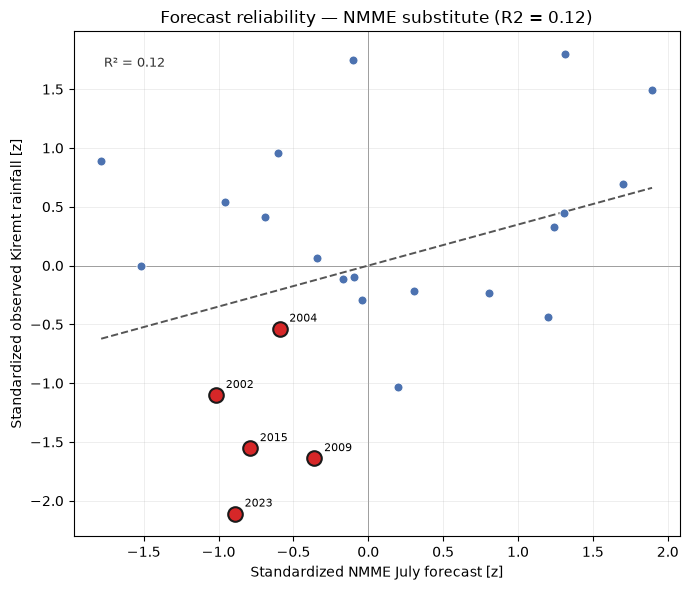

NMME July reliability R2 = 0.12  (deck's sub-seasonal ensemble ~0.48)


In [12]:
def zscore(a): return (a - a.mean()) / a.std()
fc_july    = hind_gha.sel(lat=slice(REGION[0], REGION[1]), lon=slice(REGION[2], REGION[3])).mean("member").mean(["lat","lon"])
obs_kiremt = (era.sel(time=era.time.dt.month.isin([6,7,8,9])).groupby("time.year").mean("time").mean(["lat","lon"]).sel(year=list(train)))
fx, fy = zscore(fc_july).rename("forecast_z"), zscore(obs_kiremt).rename("observed_z")
r2j = float(xr.corr(fx, fy))**2
dry_analogs = [y for y in sorted(analogs.years.tolist()) if y in list(train)]
fig = ds.plot_index_scatter(fx, fy, highlight=dry_analogs, highlight_color="#d62728", trendline=True,
        xlabel="Standardized NMME July forecast [z]", ylabel="Standardized observed Kiremt rainfall [z]",
        title=f"Forecast reliability — NMME substitute (R2 = {r2j:.2f})")
plt.show()
print(f"NMME July reliability R2 = {r2j:.2f}  (deck's sub-seasonal ensemble ~0.48)")

Our R² (~0.1) is **much lower** than the deck's ≈0.48: the slope is positive and
the dry analogs still fall low-forecast/low-observed, but the seasonal NMME does
not resolve the dry tail like the deck's tuned five-model sub-seasonal ensemble.
This is the same weakness that softens config B. It motivates reconstructing the
deck's West-Pacific leg from a different angle (§9b).

## 9 · The teleconnection cross-check (Stage 5, observational)

Dry **West Pacific** rainfall coincides with dry Ethiopian rainfall (weakened Walker circulation). The deck plots West-Pacific July rainfall against Ethiopian July (slide 19) and July–September (slide 20).

<figure style="margin:1.1em 0;padding:0.6em;border:1px solid #ddd;border-radius:8px;background:#fafafa">
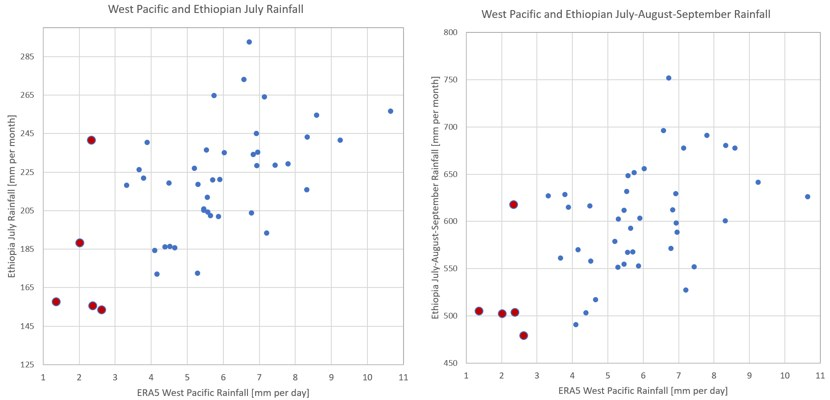
<figcaption style="font-size:0.85em;color:#555;margin-top:0.4em">
<b>CHC deck &middot; slide 19–20</b> &mdash; Slides 19–20 — West Pacific vs Ethiopian July (left) and July–September (right) rainfall</figcaption>
</figure>

The deck's exact axes — **ERA5** West-Pacific vs **CHIRPS** Ethiopian rainfall (a backward-looking check, so CHIRPS's historical record suffices):

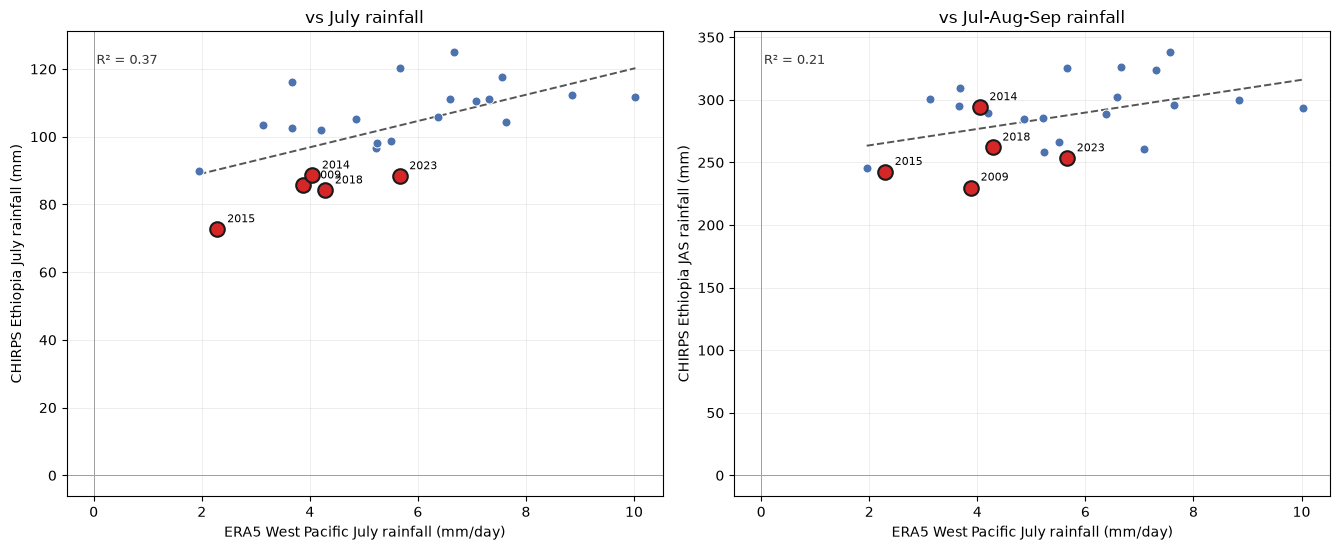

In [13]:
wpac = rosetta.fetch("obs/era5", "precip", hindcast=(2000, 2023), region=[-9, 4, 103, 140], verbose=False)["precip"]
chirps = xr.concat([rosetta.fetch("obs/chirps-v3-daily-rhiza", "precip", hindcast=(y,y), region=REGION, verbose=False)["precip"]
                    for y in range(2000, 2024)], dim="time").sortby("time")
wpac_jul = wpac.sel(time=wpac.time.dt.month == 7).groupby("time.year").mean("time").mean(["lat","lon"])
eth_jul  = chirps.sel(time=chirps.time.dt.month == 7).groupby("time.year").sum("time").mean(["lat","lon"])
eth_jas  = chirps.sel(time=chirps.time.dt.month.isin([7,8,9])).groupby("time.year").sum("time").mean(["lat","lon"])
eth_jul, eth_jas = eth_jul.sel(year=wpac_jul.year), eth_jas.sel(year=wpac_jul.year)
wpac_jul.name = "wpac_july"; driest = eth_jul.sortby(eth_jul).year.values[:5].tolist()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6))
ds.plot_index_scatter(wpac_jul, eth_jul.rename("eth_july"), ax=axes[0], highlight=driest,
        highlight_color="#d62728", trendline=True, xlabel="ERA5 West Pacific July rainfall (mm/day)",
        ylabel="CHIRPS Ethiopia July rainfall (mm)", title="vs July rainfall")
ds.plot_index_scatter(wpac_jul, eth_jas.rename("eth_jas"), ax=axes[1], highlight=driest,
        highlight_color="#d62728", trendline=True, xlabel="ERA5 West Pacific July rainfall (mm/day)",
        ylabel="CHIRPS Ethiopia JAS rainfall (mm)", title="vs Jul-Aug-Sep rainfall")
fig.tight_layout(); plt.show()

Both panels reproduce the deck's positive association — the driest Ethiopian years
(red) at the dry end of the West-Pacific axis. This is the *observed* relationship
(deck slides 19–20). The deck's **forecast** leg (slide 18) — do the models predict
a dry 2026 West Pacific? — is reconstructed next.

## 9b · The West-Pacific forecast leg (the deck's slide 18)

The deck's fourth leg is a forecast argument: a **rapid El&nbsp;Niño onset drives a
dry West Pacific**, as in 2002 and 2015, which weakens the Walker circulation and
suppresses Kiremt. We build the **NMME** West-Pacific (9°S–4°N, 103–140°E) July
precipitation forecast, standardized, and place 2026 against the history. This is
not the deck's five sub-seasonal models, so it is a weaker instrument, used to check
the *direction* of the signal:

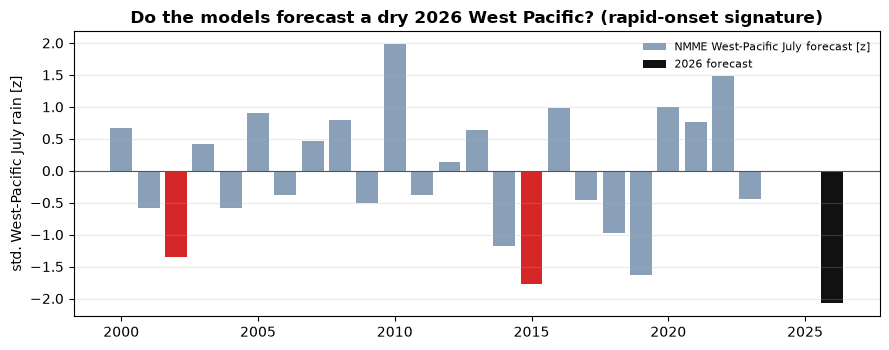

2026 West-Pacific July forecast: -2.08 z   (dry-onset analogs 2002=-1.35, 2015=-1.77)


In [14]:
WPAC = [-9, 4, 103, 140]
def nmme_wpac_july(y):
    vals = []
    for m in MODELS:
        d = rosetta.fetch(m, "precip", init=f"{y}-06", target=(datetime(y,7,1), datetime(y,7,31)),
                          hindcast=(y,y), region=WPAC, verbose=False)["precip"]
        if d.sizes.get("init_time", 0) == 0:
            continue
        v = float(d.isel(init_time=0, drop=True).mean("member").mean(["lat","lon"]))
        if v > 40:                                      # implausible rate -> reject a corrupt model-year
            continue
        vals.append(v)
    return float(np.mean(vals))

wp_years = list(range(2000, 2024)) + [TARGET]
wp = pd.Series({y: nmme_wpac_july(y) for y in wp_years})
wp_z = (wp - wp.loc[2000:2023].mean()) / wp.loc[2000:2023].std()

fig, ax = plt.subplots(figsize=(9, 3.6))
hist = wp_z.loc[2000:2023]
ax.bar(hist.index, hist.values, color="#8aa0b8", label="NMME West-Pacific July forecast [z]")
for yr in [2002, 2015]:
    if yr in hist.index: ax.bar([yr], [hist.loc[yr]], color="#d62728")
ax.bar([TARGET], [wp_z.loc[TARGET]], color="#111", label="2026 forecast")
ax.axhline(0, color="#555", lw=0.8); ax.set_ylabel("std. West-Pacific July rain [z]")
ax.set_title("Do the models forecast a dry 2026 West Pacific? (rapid-onset signature)", fontweight="bold")
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=0.25, axis="y"); fig.tight_layout(); plt.show()
print(f"2026 West-Pacific July forecast: {wp_z.loc[TARGET]:+.2f} z   "
      f"(dry-onset analogs 2002={wp_z.get(2002, float('nan')):+.2f}, 2015={wp_z.get(2015, float('nan')):+.2f})")

The sign of the 2026 forecast relative to the 2002/2015 rapid-onset years is the
reconstructed leg: a **negative** (dry) 2026 West Pacific would corroborate the
deck's rapid-onset argument from an independent forecast, a positive one would not.
Read it as *directional* corroboration only — the three-model seasonal NMME is not
the deck's dry-tail-tuned five-model sub-seasonal ensemble (§8), so it is a weaker
instrument than the deck's, and this leg should be weighted accordingly.

## 10 · Is ERA5 a defensible stand-in for CHIRPS?

Measured over 2000–2023, where both exist:

In [15]:
def jjas_total(da, per="sum"):
    s = da.sel(time=da.time.dt.month.isin([6,7,8,9])).groupby("time.year")
    return (s.sum("time") if per=="sum" else s.mean("time")*122).mean(["lat","lon"])
era_t, chp_t = xr.align(jjas_total(era, "mean"), jjas_total(chirps, "sum"), join="inner")
print(f"ERA5 vs CHIRPS JJAS totals, 2000-2023: Pearson r = {float(xr.corr(era_t, chp_t)):.2f}, "
      f"mean bias {float((era_t-chp_t).mean()):+.0f} mm")

ERA5 vs CHIRPS JJAS totals, 2000-2023: Pearson r = 0.81, mean bias -13 mm


ERA5 and CHIRPS track at **r ≈ 0.8** with a small dry bias. Because 2026 is
positioned within ERA5's *own* distribution, that mean bias largely cancels from
the percentiles. One caveat: this correspondence is a **seasonal-total, region-mean**
check — it does not certify ERA5's *pixel-level tail* behaviour over the steep
highlands, so the deepest "driest-on-record" pixels (especially in the wet
south-west) should be read cautiously.

## Recap

Three `fetch` calls (ERA5, ERSSTv5, NMME) and a sequence of DeepScale operations
rebuild the SMPG stages for 2026: the observed-to-date monitoring (§2), an
ENSO-forecast-anchored moderate-to-very-strong analog set (§3), the ENSO–rainfall
relationship and below-normal composite (§4), the scenario completion at pixel,
region, and woreda level (§5–6), the dynamic-forecast configuration (§7) and its
reliability check (§8), and the West-Pacific teleconnection — observed (§9) and
forecast (§9b).

The analog-driven outlook — the part independent of the substituted forecast —
matches the deck closely: a widespread poor Kiremt, with the West-Pacific forecast
pointing the same way. The one leg that diverges is the dynamic forecast: the NMME
July is near climatology and softens the outlook, where the deck's drier CHIRPS-GEFS
sharpened it. The outlook is conditional on the forecast El&nbsp;Niño developing, so
its confidence tracks that of the ENSO forecast.